In [1]:
import sys
import os

os.environ["TF_USE_LEGACY_KERAS"] = "1"

import tf_keras as keras
sys.modules["tensorflow.keras"] = keras
sys.modules["keras"] = keras

import keras_tuner as kt
import qkeras
from qkeras import QDense, QConv2D, QActivation
from qkeras.quantizers import quantized_bits, quantized_relu

import tensorflow as tf
from tf_keras.models import Sequential
from tf_keras.layers import MaxPooling2D, Activation, Flatten, Dropout
import numpy as np

ModuleNotFoundError: No module named 'tf_keras'

In [3]:
input_shape = (28, 28, 1)

# Load the data and split it between train and test sets
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

# Scale images to the [0, 1] range
X_train = X_train.astype("float32") / 255
X_test = X_test.astype("float32") / 255

# Make sure images have shape (28, 28, 1)
X_train = np.expand_dims(X_train, -1)
X_test = np.expand_dims(X_test, -1)
print("X_train shape:", X_train.shape)
print(X_train.shape[0], "train samples")
print(X_test.shape[0], "test samples")

N_train = int(0.9 * len(X_train))
X_train, X_val = X_train[:N_train], X_train[N_train:]
y_train, y_val = y_train[:N_train], y_train[N_train:]

# Convert class vectors to binary class matrices
y_train = keras.utils.to_categorical(y_train, 10)
y_val = keras.utils.to_categorical(y_val, 10)
y_test = keras.utils.to_categorical(y_test, 10)

X_train shape: (60000, 28, 28, 1)
60000 train samples
10000 test samples


In [ ]:
#import tf_keras as keras
#import tensorflow as tf
#from qkeras import QDense, QConv2D, QActivation, quantized_bits, quantized_relu


inputs = keras.Input(shape=input_shape)

x = QConv2D(
    filters=32,
    kernel_size=(3, 3),
    name='qconv1',
    kernel_quantizer=quantized_bits(4, 0, alpha=1),
    bias_quantizer=quantized_bits(4, 0, alpha=1),
    kernel_initializer='lecun_uniform',
    kernel_regularizer=keras.regularizers.l1(1e-4)
)(inputs)

x = QActivation(activation=quantized_relu(4), name='relu1')(x)
x = keras.layers.MaxPooling2D(pool_size=(2, 2), name="pool1")(x)
x = QConv2D(
    filters=32,
    kernel_size=(3, 3),
    name='qconv2',
    kernel_quantizer=quantized_bits(4, 0, alpha=1),
    bias_quantizer=quantized_bits(4, 0, alpha=1),
    kernel_initializer='lecun_uniform',
    kernel_regularizer=keras.regularizers.l1(1e-4)
)(x)

x = QActivation(activation=quantized_relu(4), name='relu2')(x)
x = keras.layers.MaxPooling2D(pool_size=(2, 2), name="pool2")(x)

x = keras.layers.Flatten()(x)
x = keras.layers.Dropout(0.4)(x)

x = QDense(
    10,
    name='qdense1',
    kernel_quantizer=quantized_bits(4, 0, alpha=1),
    bias_quantizer=quantized_bits(4, 0, alpha=1),
    kernel_initializer='lecun_uniform',
    kernel_regularizer=keras.regularizers.l1(1e-4)
)(x)

outputs = keras.layers.Activation(activation='softmax', name='softmax')(x)
model = keras.Model(inputs=inputs, outputs=outputs)

model.summary()

Model: "model_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_5 (InputLayer)        [(None, 28, 28, 1)]       0         
                                                                 
 qconv1 (QConv2D)            (None, 26, 26, 32)        320       
                                                                 
 relu1 (QActivation)         (None, 26, 26, 32)        0         
                                                                 
 pool1 (MaxPooling2D)        (None, 13, 13, 32)        0         
                                                                 
 qconv2 (QConv2D)            (None, 11, 11, 32)        9248      
                                                                 
 relu2 (QActivation)         (None, 11, 11, 32)        0         
                                                                 
 pool2 (MaxPooling2D)        (None, 5, 5, 32)          0   

In [ ]:
import tensorflow_model_optimization as tfmot
from tensorflow_model_optimization.sparsity import keras as sparsity

#Calculate endstep based on the dataset size and batch size
batch_size = 128
epochs = 15
num_samples = len(X_train) * 0.75 
steps_per_epoch = np.ceil(num_samples / batch_size).astype(np.int32)
end_step = steps_per_epoch * epochs

pruning_params = {
    'pruning_schedule': sparsity.PolynomialDecay(
        initial_sparsity=0.0,
        final_sparsity=0.75, # Target 75% sparsity
        begin_step=0,
        end_step=end_step
    )
}
model = tfmot.sparsity.keras.prune_low_magnitude(model, **pruning_params)

callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=2,restore_best_weights=True),
    
    #pruning specific
    sparsity.UpdatePruningStep(), 
    sparsity.PruningSummaries(log_dir='model_pruned/logs')
]

In [37]:
opt = keras.optimizers.Adam(learning_rate=1e-3)
model.compile(loss="categorical_crossentropy", optimizer=opt, metrics=["accuracy"])

In [ ]:
model.fit(X_train, y_train, batch_size=batch_size, epochs=epochs, callbacks=callbacks, validation_data=(X_test, y_test), shuffle=True)
model = sparsity.strip_pruning(model) # Strip the wrappers to get the plain Keras model back

Epoch 1/15


/home/slopin/DAT255-project/.venv_qkeras2/lib/python3.10/site-packages/tf_keras/src/constraints.py:365: UserWarning: The `keras.constraints.serialize()` API should only be used for objects of type `keras.constraints.Constraint`. Found an instance of type <class 'qkeras.quantizers.quantized_bits'>, which may lead to improper serialization.
  warnings.warn(
E0000 00:00:1777371102.342840    5549 meta_optimizer.cc:966] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape ingradient_tape/model_4/prune_low_magnitude_relu2/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


422/422 [==============================] - 12s 21ms/step - loss: 0.5332 - accuracy: 0.8747 - val_loss: 0.2330 - val_accuracy: 0.9624
Epoch 2/15
422/422 [==============================] - 8s 20ms/step - loss: 0.2465 - accuracy: 0.9565 - val_loss: 0.1828 - val_accuracy: 0.9728
Epoch 3/15
422/422 [==============================] - 9s 20ms/step - loss: 0.2100 - accuracy: 0.9637 - val_loss: 0.1611 - val_accuracy: 0.9782
Epoch 4/15
422/422 [==============================] - 9s 21ms/step - loss: 0.1913 - accuracy: 0.9683 - val_loss: 0.1506 - val_accuracy: 0.9794
Epoch 5/15
422/422 [==============================] - 9s 21ms/step - loss: 0.1815 - accuracy: 0.9701 - val_loss: 0.1439 - val_accuracy: 0.9802
Epoch 6/15
422/422 [==============================] - 8s 20ms/step - loss: 0.1714 - accuracy: 0.9720 - val_loss: 0.1330 - val_accuracy: 0.9824
Epoch 7/15
422/422 [==============================] - 8s 20ms/step - loss: 0.1680 - accuracy: 0.9722 - val_loss: 0.1319 - val_accuracy: 0.9835
Epoch 8/1

% of zeros = 0.75


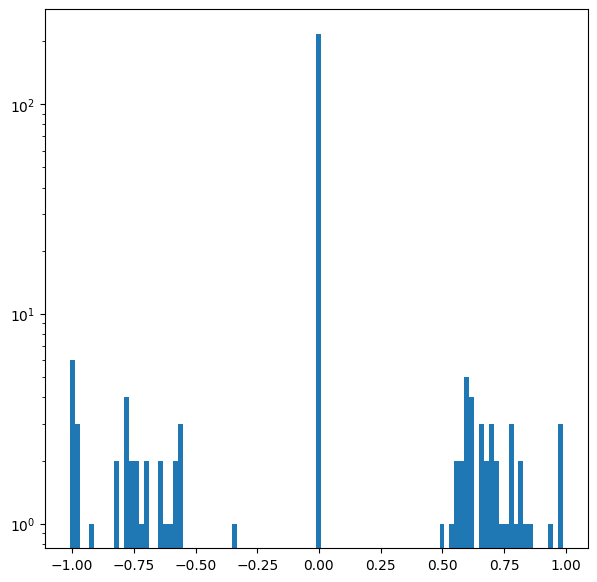

In [52]:
import numpy as np
import matplotlib.pyplot as plt

w = model.layers[1].weights[0].numpy()
h, b = np.histogram(w, bins=100)
plt.figure(figsize=(7, 7))
plt.bar(b[:-1], h, width=b[1] - b[0])
plt.semilogy()
print('% of zeros = {}'.format(np.sum(w == 0) / np.size(w)))

In [53]:
model.compile(loss="categorical_crossentropy", optimizer=opt, metrics=["accuracy"]) #Has to be compiled again after stripping the pruning wrappers

score = model.evaluate(X_test, y_test, verbose=0)
print("Test loss:", score[0])
print("Test accuracy:", score[1])

Test loss: 0.11839234828948975
Test accuracy: 0.9850000143051147


In [54]:
model.save('Model_Qkeras_6bw_pruned.h5')

/home/slopin/DAT255-project/.venv_qkeras2/lib/python3.10/site-packages/tf_keras/src/engine/training.py:3098: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native TF-Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
/home/slopin/DAT255-project/.venv_qkeras2/lib/python3.10/site-packages/tf_keras/src/constraints.py:365: UserWarning: The `keras.constraints.serialize()` API should only be used for objects of type `keras.constraints.Constraint`. Found an instance of type <class 'qkeras.quantizers.quantized_bits'>, which may lead to improper serialization.
  warnings.warn(
